In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:
df = pd.read_csv("SleepStudyData.csv")
df.head()


,Enough,Hours,PhoneReach,PhoneTime,Tired,Breakfast
0,Yes,8.0,Yes,Yes,3,Yes
1,No,6.0,Yes,Yes,3,No
2,Yes,6.0,Yes,Yes,2,Yes
3,No,7.0,Yes,Yes,4,No
4,No,7.0,Yes,Yes,2,Yes


In [46]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Enough      104 non-null    object 
 1   Hours       102 non-null    float64
 2   PhoneReach  104 non-null    object 
 3   PhoneTime   104 non-null    object 
 4   Tired       104 non-null    int64  
 5   Breakfast   104 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 5.0+ KB


In [47]:
df.describe()

,Hours,Tired
count,102.000000,104.000000
mean,6.656863,3.076923
std,1.417676,1.011510
min,2.000000,1.000000
25%,6.000000,2.000000
50%,7.000000,3.000000
75%,7.000000,4.000000
max,10.000000,5.000000


In [48]:
df.shape


(104, 6)

In [50]:
df.isnull().sum()


Enough        0
Hours         2
PhoneReach    0
PhoneTime     0
Tired         0
Breakfast     0
dtype: int64

C:\Users\kiran\AppData\Local\Temp\ipykernel_4844\1129578496.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Enough', data=df, palette='Set2')


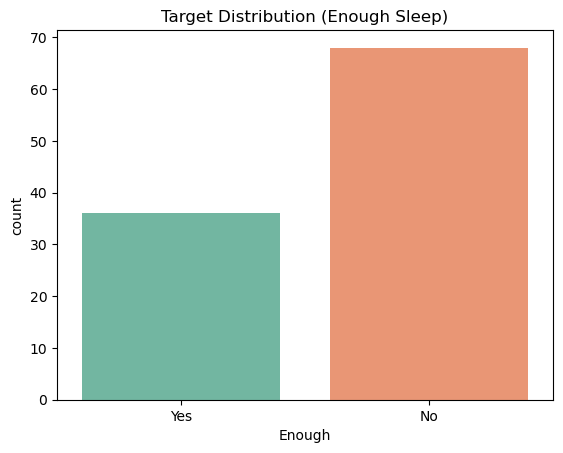

In [51]:
sns.countplot(x='Enough', data=df, palette='Set2')
plt.title("Target Distribution (Enough Sleep)")
plt.show()


In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Enough', 'PhoneReach', 'PhoneTime', 'Breakfast']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,Enough,Hours,PhoneReach,PhoneTime,Tired,Breakfast
0,1,8.0,1,1,3,1
1,0,6.0,1,1,3,0
2,1,6.0,1,1,2,1
3,0,7.0,1,1,4,0
4,0,7.0,1,1,2,1


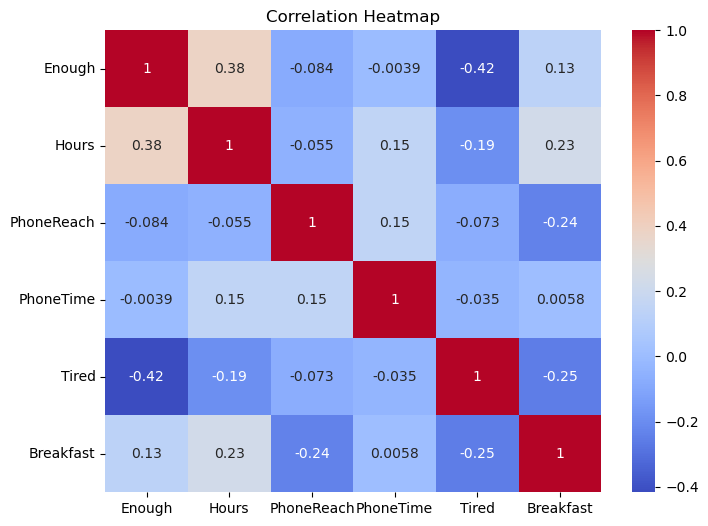

In [53]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [54]:
X = df.drop('Enough', axis=1)
y = df['Enough']

X.head(), y.head()


(   Hours  PhoneReach  PhoneTime  Tired  Breakfast
 0    8.0           1          1      3          1
 1    6.0           1          1      3          0
 2    6.0           1          1      2          1
 3    7.0           1          1      4          0
 4    7.0           1          1      2          1,
 0    1
 1    0
 2    1
 3    0
 4    0
 Name: Enough, dtype: int64)

In [59]:
# STEP 7: Handle missing values BEFORE SMOTE
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Impute missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Apply SMOTE
smote = SMOTE(k_neighbors=3, random_state=42)
X, y = smote.fit_resample(X, y)

# Convert back to DataFrame
X = pd.DataFrame(X)

# Check class balance
y.value_counts()


Enough
1    68
0    68
Name: count, dtype: int64

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X)


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

model_LR = LogisticRegression(max_iter=1000)
model_DT = DecisionTreeClassifier(random_state=42)
model_RF = RandomForestClassifier(random_state=42)
model_SVM = SVC()

model_LR.fit(X, y)
model_DT.fit(X, y)
model_RF.fit(X, y)
model_SVM.fit(X, y)


SVC()

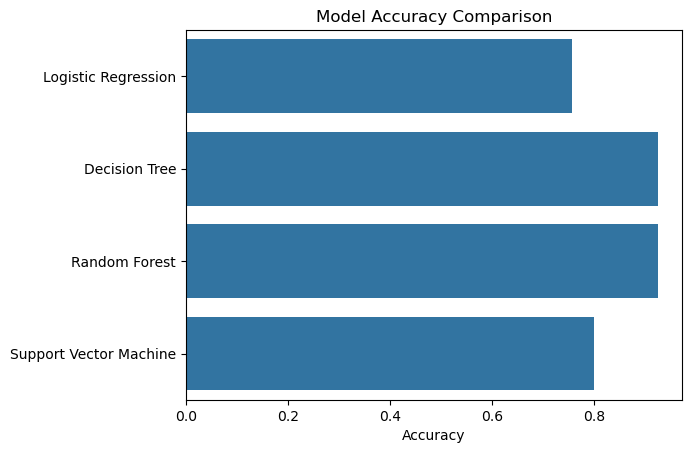

In [62]:
Accuracy = [
    model_LR.score(X, y),
    model_DT.score(X, y),
    model_RF.score(X, y),
    model_SVM.score(X, y)
]

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Support Vector Machine'
]

sns.barplot(x=Accuracy, y=models)
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [63]:
import pickle

pickle.dump(model_RF, open("sleep_model.sav", "wb"))
pickle.dump(scaler, open("sleep_scaler.sav", "wb"))


In [ ]:
import numpy as np
import pickle

# Load model and scaler
model = pickle.load(open("sleep_model.sav", "rb"))
scaler = pickle.load(open("sleep_scaler.sav", "rb"))

print("Enter values for prediction")

Hours = float(input("Hours of Sleep: "))
PhoneReach = int(input("Phone Reachable (Yes=1, No=0): "))
PhoneTime = int(input("Used Phone Before Sleep (Yes=1, No=0): "))
Tired = float(input("Tired Level (1-5): "))
Breakfast = int(input("Had Breakfast (Yes=1, No=0): "))

input_data = np.array([[Hours, PhoneReach, PhoneTime, Tired, Breakfast]])

# Scale input
input_scaled = scaler.transform(input_data)

# Predict
prediction = model.predict(input_scaled)

if prediction[0] == 1:
    print("\nPrediction: Enough Sleep ✅")
else:
    print("\nPrediction: Not Enough Sleep ❌")


Enter values for prediction
